# Source B — Key Findings: BLS Quarterly Census of Employment and Wages

This notebook shows the most important, already-verified results from
`analysis-output/source-b/source-b-findings.md`. It loads existing computed
artifacts (`source_b_stats.json`, saved figures, industry-mix/crossvalidation
CSVs) rather than re-running the full pipeline.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent.parent if Path.cwd().name == "source-b" else Path.cwd()
FIGURES_DIR = REPO_ROOT / "analysis-output" / "source-b" / "figures"

with open(REPO_ROOT / "analysis-output" / "source-b" / "source_b_stats.json") as f:
    stats = json.load(f)
stats

{'total_counties': 3143,
 'dominant_sector_counts': {'Manufacturing': 695,
  'Agriculture, Forestry, Fishing & Hunting': 489,
  'Mining, Quarrying, Oil & Gas': 367,
  'Utilities': 268,
  'Retail Trade': 180,
  'Construction': 156,
  'Unclassified': 139,
  'Transportation & Warehousing': 136,
  'Wholesale Trade': 126,
  'Arts, Entertainment & Recreation': 107,
  'Accommodation & Food Services': 81,
  'Health Care & Social Assistance': 73,
  'Educational Services': 71,
  'Other Services (except Public Administration)': 52,
  'Management of Companies & Enterprises': 47,
  'Finance & Insurance': 44,
  'Real Estate & Rental & Leasing': 29,
  'Information': 25,
  'Professional, Scientific & Technical Services': 24,
  'Administrative & Support & Waste Management': 24,
  'Not classified': 10},
 'dominant_sector_rates': {'Manufacturing': 0.22112631244034361,
  'Agriculture, Forestry, Fishing & Hunting': 0.15558383709831372,
  'Mining, Quarrying, Oil & Gas': 0.11676741966274261,
  'Utilities': 0

## 1. Dataset

3,143 of 3,144 US counties/county-equivalents (Kalawao County, HI has no QCEW
private-sector county-level row at all), each with 20 NAICS-2 sector Location
Quotients (`lq_emp_*`) plus matching `disclosure_*` suppression flags, for 2025
Q4, Private ownership. Pulled from BLS QCEW's bulk quarterly singlefile.

In [2]:
source_b_df = pd.read_parquet(REPO_ROOT / "data" / "source_b_qcew.parquet")
print(f"{len(source_b_df):,} counties")
source_b_df[["county_name", "fips_code", "lq_emp_31-33", "lq_emp_21", "disclosure_21"]].head()

3,143 counties


,county_name,fips_code,lq_emp_31-33,lq_emp_21,disclosure_21
0,"Autauga County, Alabama",01001,1.86,NaN,True
1,"Baldwin County, Alabama",01003,0.60,0.33,False
2,"Barbour County, Alabama",01005,3.46,2.65,False
3,"Bibb County, Alabama",01007,1.56,NaN,True
4,"Blount County, Alabama",01009,1.84,NaN,True


## 2. Finding: Dominant Sector Breakdown -- Production/Extraction, Not Services

Manufacturing, Agriculture, Mining, and Utilities together account for 57.9% of
all counties' dominant (highest-LQ) sector -- county-level industrial structure
in the US is overwhelmingly production/extraction-driven, not concentrated in
tertiary/service sectors, each of which individually accounts for under 6% of
counties even at their most common. 10 counties (0.3%) have no dominant sector
at all -- every one of the 20 sectors is either suppressed or absent -- and all
10 are sparsely populated rural counties.

Dominant sector counts: {'Manufacturing': 695, 'Agriculture, Forestry, Fishing & Hunting': 489, 'Mining, Quarrying, Oil & Gas': 367, 'Utilities': 268, 'Retail Trade': 180, 'Construction': 156, 'Unclassified': 139, 'Transportation & Warehousing': 136, 'Wholesale Trade': 126, 'Arts, Entertainment & Recreation': 107, 'Accommodation & Food Services': 81, 'Health Care & Social Assistance': 73, 'Educational Services': 71, 'Other Services (except Public Administration)': 52, 'Management of Companies & Enterprises': 47, 'Finance & Insurance': 44, 'Real Estate & Rental & Leasing': 29, 'Information': 25, 'Professional, Scientific & Technical Services': 24, 'Administrative & Support & Waste Management': 24, 'Not classified': 10}


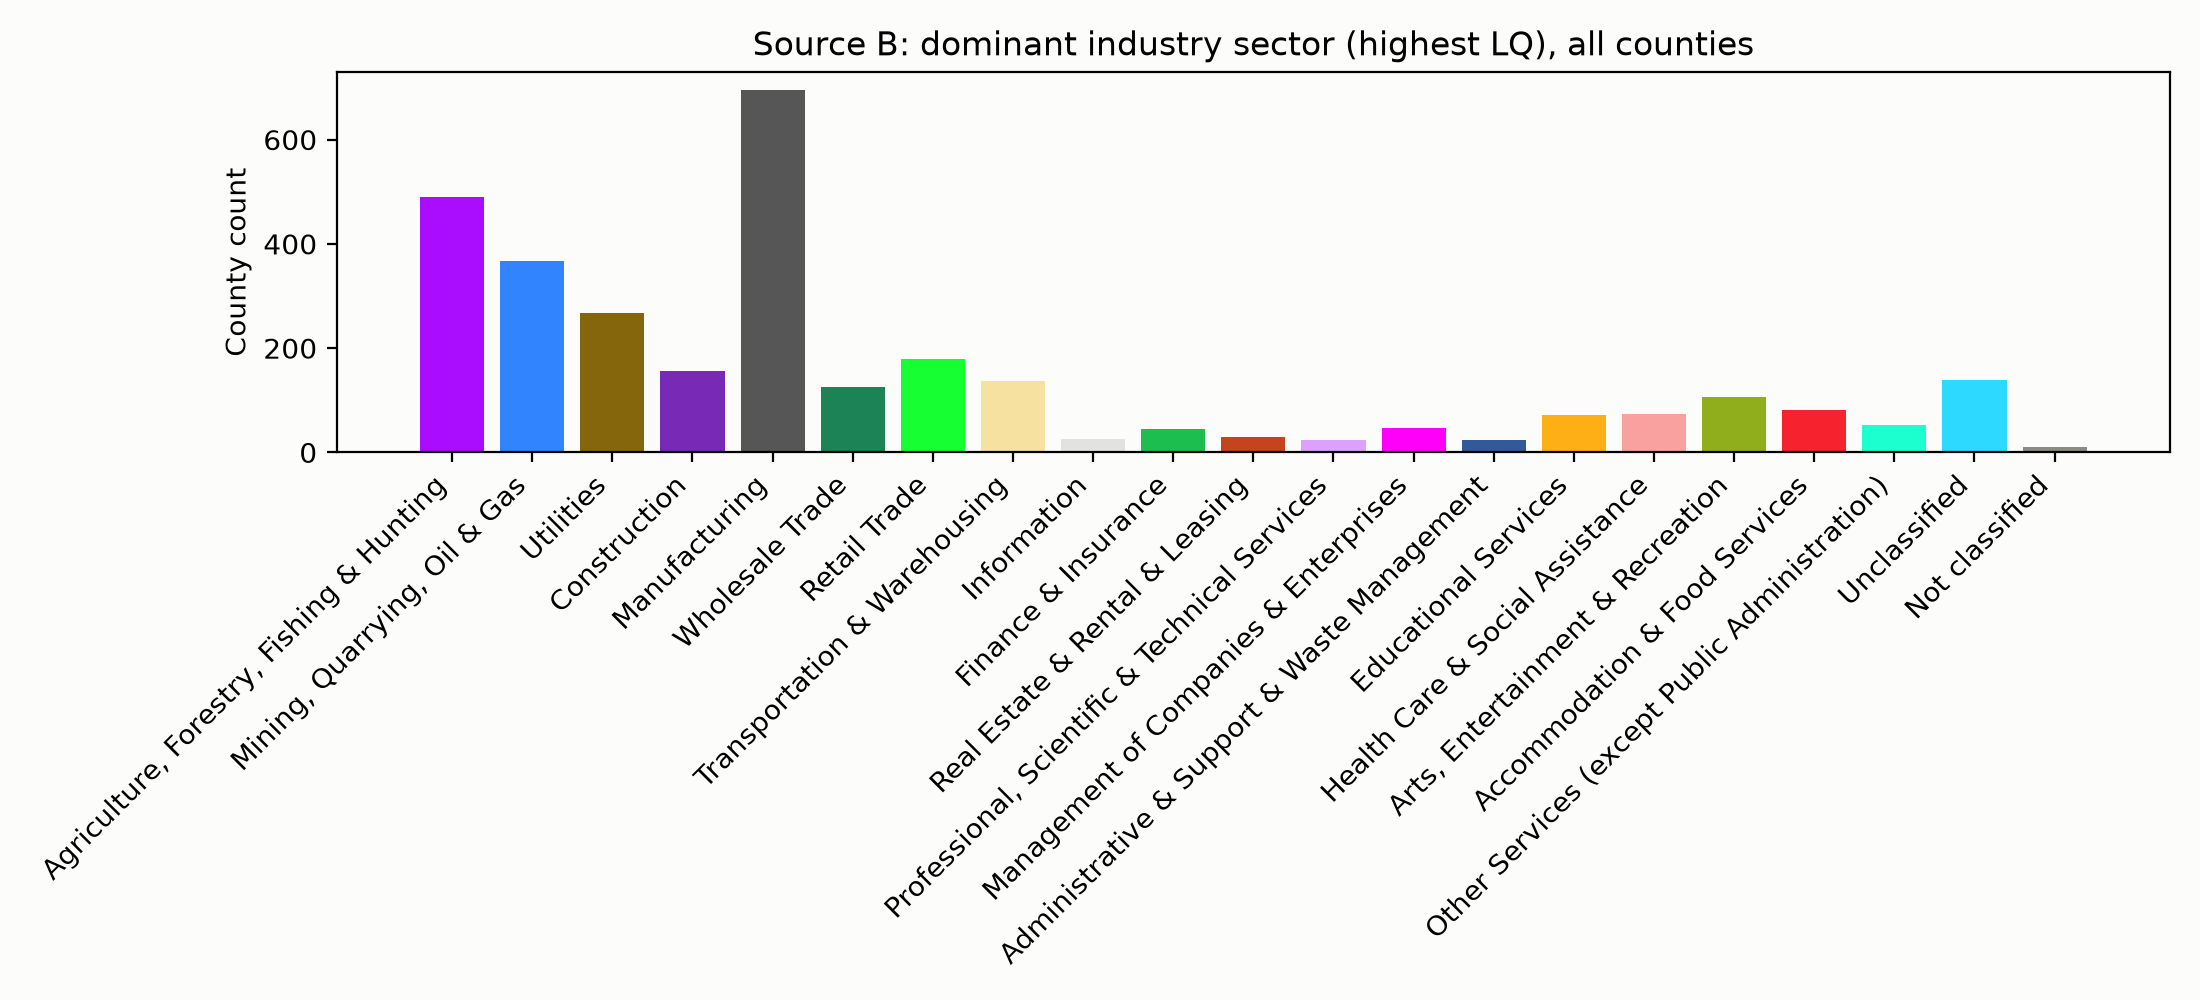

In [3]:
print("Dominant sector counts:", stats["dominant_sector_counts"])
display(Image(filename=str(FIGURES_DIR / "source-b-figure-01-dominant-sector.png")))

## 3. Finding: Extreme Specialization Is Real, Not an Artifact

The most specialized county nationally is Eureka County, NV (dominant LQ =
248.09, Mining). The rest of the top 25 are, with one exception, real
single-industry economies -- West/South Texas oil & gas counties (Permian
Basin, Eagle Ford, and Panhandle/Anadarko), Alaska oil counties (North Slope
Borough, the 2nd-highest LQ nationally), Nevada mining counties, North Dakota
Bakken counties, Oklahoma and Georgia mining, and two Nebraska agriculture
counties. The one non-mining/agriculture entry, Surry County, VA (LQ = 102.34,
Utilities), is home to the Surry Nuclear Power Station -- exactly the kind of
single-facility county the LQ metric is designed to surface.

In [4]:
industry_mix = pd.read_csv(REPO_ROOT / "outputs" / "source_b_industry_mix.csv")
industry_mix.nlargest(10, "dominant_lq")[["county_name", "dominant_industry", "dominant_lq"]]

,county_name,dominant_industry,dominant_lq
1753,"Eureka County, Nevada","Mining, Quarrying, Oil & Gas",248.09
87,"North Slope Borough, Alaska","Mining, Quarrying, Oil & Gas",136.08
2641,"Irion County, Texas","Mining, Quarrying, Oil & Gas",134.60
1760,"Pershing County, Nevada","Mining, Quarrying, Oil & Gas",121.74
2153,"Dewey County, Oklahoma","Mining, Quarrying, Oil & Gas",110.39
1752,"Esmeralda County, Nevada","Mining, Quarrying, Oil & Gas",108.15
2771,"Winkler County, Texas","Mining, Quarrying, Oil & Gas",103.04
2907,"Surry County, Virginia",Utilities,102.34
2665,"La Salle County, Texas","Mining, Quarrying, Oil & Gas",91.46
2715,"Reagan County, Texas","Mining, Quarrying, Oil & Gas",88.16


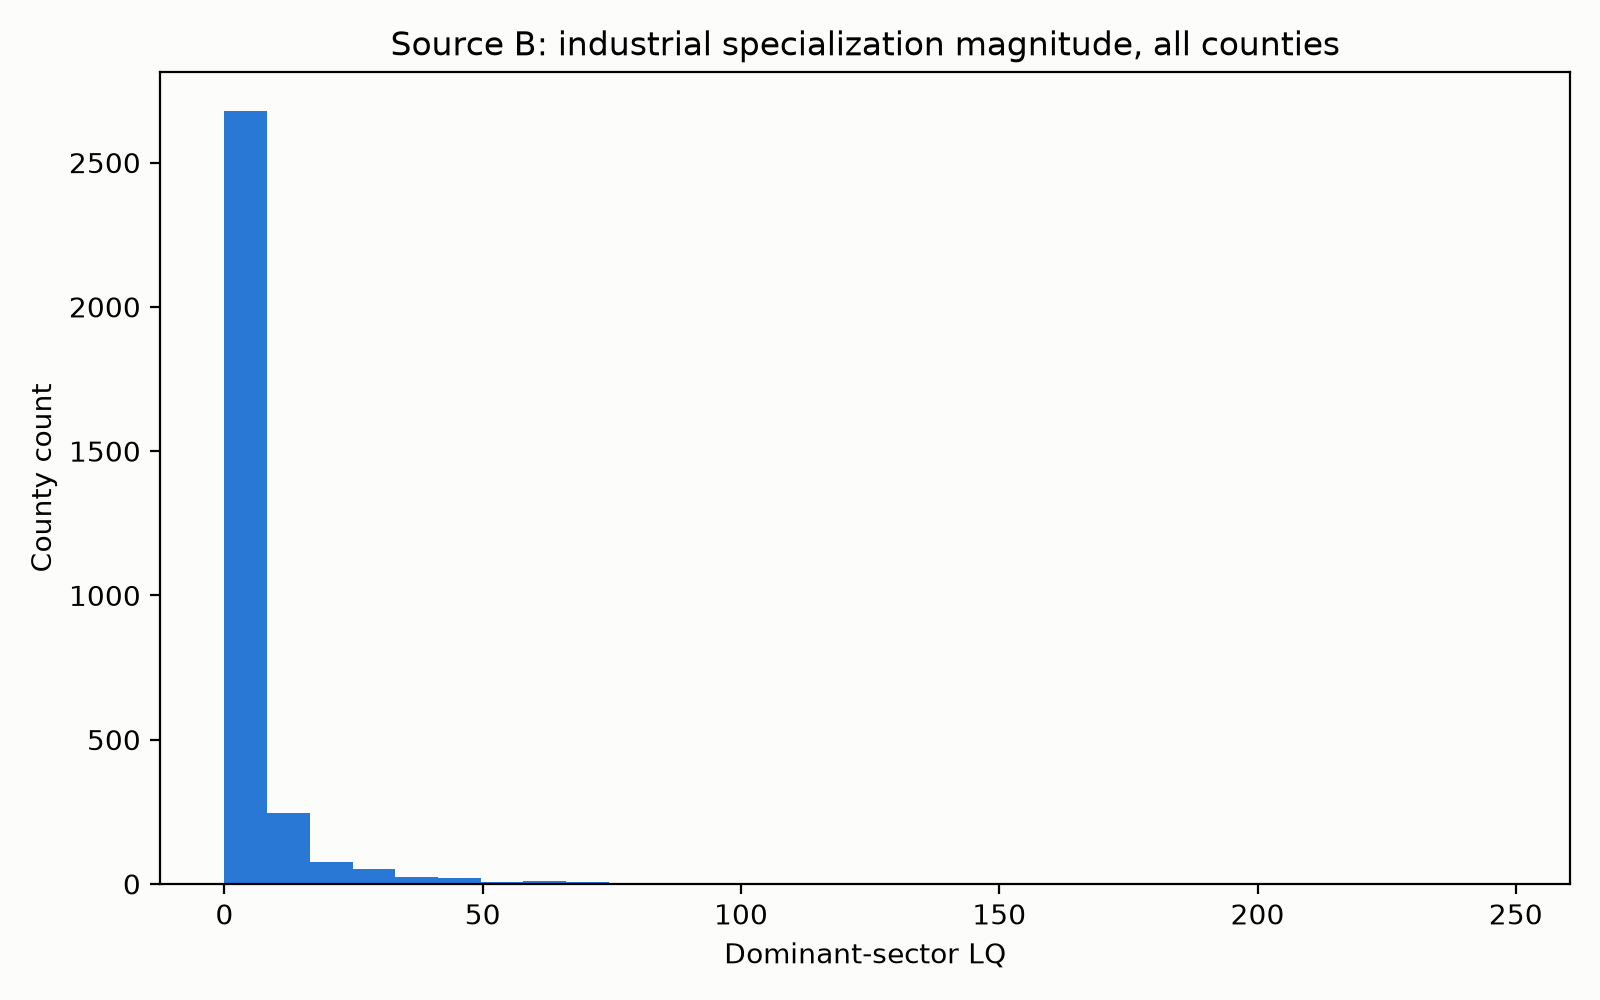

In [5]:
display(Image(filename=str(FIGURES_DIR / "source-b-figure-02-specialization-distribution.png")))

## 4. Finding: Suppression Handled as Honest Nulls, Not Estimated

BLS suppresses 30.0% of county x sector cells nationally for small-employer
privacy. `source_b_plan.md` Phase 1b empirically tested a state-level LQ
fallback and a proportional-allocation proxy for the spec's proposed IPF fix --
both barely beat a global-mean baseline and were statistically indistinguishable
from each other -- so Source B ships null-passthrough with the `disclosure_*`
flags preserved as explicit nullability markers.

In [6]:
disclosure_cols = [c for c in source_b_df.columns if c.startswith("disclosure_")]
suppression_rate = source_b_df[disclosure_cols].stack().mean()
print(f"Overall suppression rate: {suppression_rate * 100:.1f}%")

Overall suppression rate: 30.0%


## 5. Finding: Sector Identity Predicts Growth Better Than Specialization Magnitude

A county's raw specialization magnitude (`dominant_lq`) is only weakly related
to Source C's economic velocity. But which *specific* sector dominates matters
more: Real Estate & Rental & Leasing LQ correlates with size-normalized GDP
velocity at r=0.206, Wholesale Trade at r=-0.157, and Construction at r=0.154 --
all surviving Benjamini-Hochberg FDR correction across the full 20-sector scan.

In [7]:
print("dominant_lq vs unemployment velocity r =", stats["dominant_lq_vs_unemployment_velocity_corr"])
print("dominant_lq vs gdp_velocity_pct r =", stats["dominant_lq_vs_gdp_velocity_pct_corr"])
print()
pd.DataFrame(stats["top_sector_correlations"])[["label", "corr", "p_adj", "n"]]

dominant_lq vs unemployment velocity r = -0.09501397848541429
dominant_lq vs gdp_velocity_pct r = 0.04577006400771735



,label,corr,p_adj,n
0,Real Estate & Rental & Leasing,0.205910,0.006667,2396
1,Wholesale Trade,-0.157150,0.006667,2307
2,Construction,0.153874,0.006667,2435


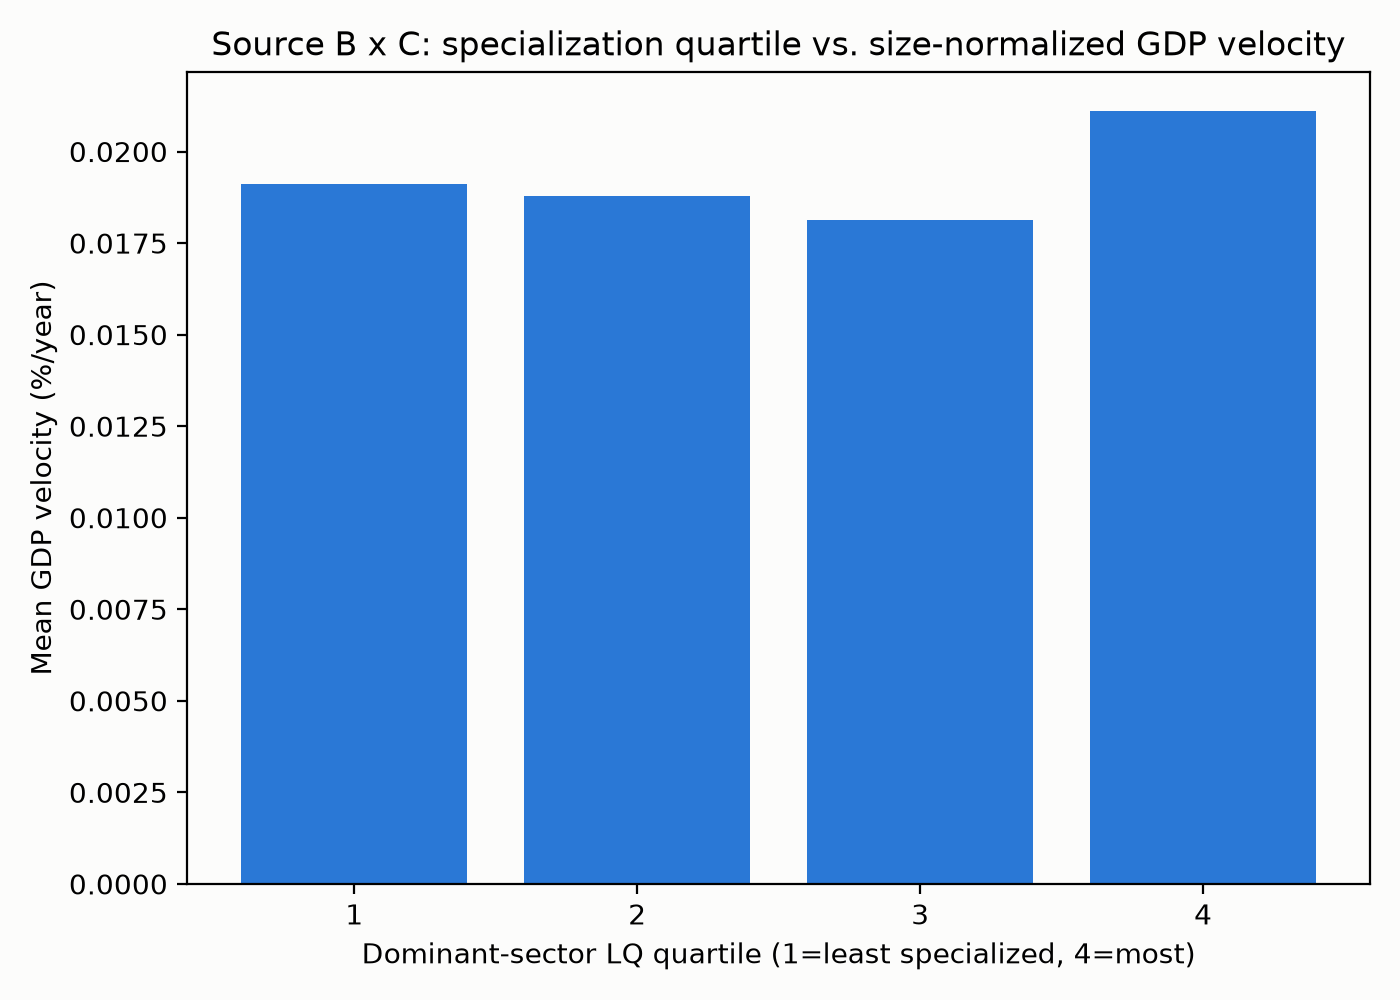

In [8]:
display(Image(filename=str(FIGURES_DIR / "source-b-figure-03-specialization-vs-velocity.png")))

## 6. Limitation: Per-Sector Correlations Rest on Suppression-Biased Subsamples

BLS suppression targets small-establishment counties non-randomly, so each
sector's correlation in §5 is computed only over the counties where that sector
happens to be large enough to disclose. The n >= 100 floor applied before
ranking reduces but does not eliminate this bias -- it isn't corrected for
statistically this round.

In [9]:
pd.DataFrame(stats["top_sector_correlations"])[["label", "n"]]

,label,n
0,Real Estate & Rental & Leasing,2396
1,Wholesale Trade,2307
2,Construction,2435


## 7. Proposal Alignment Summary

See `analysis-output/source-b/source-b-findings.md` section 8 for the full
assessment. Short version: the LQ-per-NAICS-2 mechanism works exactly as the
proposal describes, and the spec's own proposed suppression fix (IPF) was
tested via a cheaper, correctly-specified proxy and found no better than a
plain state-level fallback -- both barely beat a global-mean baseline, so
Source B ships honest nulls instead. The proposal's "what kind of growth"
framing is validated more specifically than stated: it's sector *identity*,
not specialization *magnitude*, that tracks GDP momentum.